In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv("top_colleges_2022.csv")

df.head()

,rank,organizationName,state,studentPopulation,campusSetting,medianBaseSalary,city,state.1,region,yearFounded,stateCode,collegeType,studentFacultyRatio,totalStudentPop,undergradPop,totalGrantAid,percentOfStudentsFinAid,percentOfStudentsGrant
0,1,Massachusetts Institute of Technology,MA,12195,Urban,173700.0,Cambridge,Massachusetts,Northeast,1861.0,MA,Private not-for-profit,3,12195,4582,35299332.0,75.0,60.0
1,2,Stanford University,CA,20961,Suburban,173500.0,Stanford,California,West,1891.0,CA,Private not-for-profit,4,20961,8464,51328461.0,70.0,55.0
2,2,"University of California, Berkeley",CA,45878,Urban,154500.0,Berkeley,California,West,1868.0,CA,Public,19,45878,33208,64495611.0,63.0,53.0
3,4,Princeton University,NJ,8532,Urban,167600.0,Princeton,New Jersey,Northeast,1746.0,NJ,Private not-for-profit,4,8532,5516,44871096.0,62.0,61.0
4,5,Columbia University,NY,33882,Urban,148800.0,New York,New York,Northeast,1754.0,NY,Private not-for-profit,6,33882,8689,44615007.0,58.0,54.0


In [3]:
features = [
    "medianBaseSalary",
    "studentFacultyRatio",
    "percentOfStudentsFinAid",
    "percentOfStudentsGrant",
    "totalStudentPop"
]

college_name_col = "organizationName" 

X = df[features].copy()

# Fill missing values with column medians
X = X.fillna(X.median())

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

In [5]:
similarity_matrix = cosine_similarity(X_scaled)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=df[college_name_col],
    columns=df[college_name_col]
)

similarity_df.head()

organizationName,Massachusetts Institute of Technology,Stanford University,"University of California, Berkeley",Princeton University,Columbia University,"University of California, Los Angeles",Williams College,Yale University,Duke University,University of Pennsylvania,...,Saint Francis University,College of Idaho,Loyola University New Orleans,Xavier University,The University of Texas of the Permian Basin,St. Joseph's College (NY),Moravian University,Lawrence Technological University,Saint Martin's University,University of Memphis
organizationName,,,,,,,,,,,,,,,,,,,,,
Massachusetts Institute of Technology,1.000000,0.985733,0.508880,0.970785,0.824877,0.325746,0.906561,0.957367,0.917864,0.890400,...,-0.674704,-0.130415,-0.546815,-0.378504,-0.899397,-0.514011,-0.232987,0.103516,-0.457621,-0.884874
Stanford University,0.985733,1.000000,0.632429,0.969199,0.899116,0.467905,0.908506,0.976253,0.954846,0.950914,...,-0.783560,-0.287210,-0.671299,-0.504822,-0.959352,-0.635636,-0.381902,-0.057159,-0.592032,-0.887482
"University of California, Berkeley",0.508880,0.632429,1.000000,0.542379,0.744332,0.954288,0.506255,0.608327,0.664956,0.771971,...,-0.957758,-0.849443,-0.963892,-0.927347,-0.788560,-0.973620,-0.901524,-0.706274,-0.979789,-0.608876
Princeton University,0.970785,0.969199,0.542379,1.000000,0.874567,0.339175,0.965260,0.988200,0.953498,0.923829,...,-0.717121,-0.221542,-0.607237,-0.466239,-0.907050,-0.575005,-0.320355,0.003083,-0.511704,-0.930086
Columbia University,0.824877,0.899116,0.744332,0.874567,1.000000,0.636056,0.851528,0.930022,0.949231,0.983051,...,-0.888831,-0.578428,-0.826087,-0.673191,-0.967486,-0.768947,-0.630292,-0.401344,-0.760778,-0.770612


In [6]:
# Build a similarity graph: each college is a node, edges connect colleges whose
# feature vectors have cosine similarity >= threshold. Higher threshold = sparser
# graph that is easier to visualize and shows only the strongest peer relationships.
G = nx.Graph()

for i, row in df.iterrows():
    G.add_node(
        row[college_name_col],
        cluster=int(row["cluster"]),
        state=row["state"],
        region=row["region"],
        collegeType=row["collegeType"],
        medianBaseSalary=float(row["medianBaseSalary"]) if pd.notna(row["medianBaseSalary"]) else 0.0,
        totalStudentPop=int(row["totalStudentPop"]) if pd.notna(row["totalStudentPop"]) else 0
    )

threshold = 0.95

for i in range(len(df)):
    for j in range(i + 1, len(df)):
        similarity = similarity_matrix[i][j]
        if similarity >= threshold:
            G.add_edge(
                df.iloc[i][college_name_col],
                df.iloc[j][college_name_col],
                weight=float(similarity)
            )

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Average degree:", round(sum(dict(G.degree()).values()) / G.number_of_nodes(), 2))

Number of nodes: 498
Number of edges: 3756
Average degree: 15.08


In [7]:
# Compute centrality metrics. Degree = how many similar peers a college has.
# Betweenness = how often a college sits on the shortest path between others
# (a "bridge" between different kinds of schools).
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, weight="weight")
clustering_coef = nx.clustering(G, weight="weight")

centrality_df = pd.DataFrame({
    "college": list(degree_centrality.keys()),
    "degree": [G.degree(n) for n in degree_centrality.keys()],
    "degree_centrality": list(degree_centrality.values()),
    "betweenness_centrality": list(betweenness_centrality.values()),
    "clustering_coefficient": list(clustering_coef.values()),
    "cluster": [G.nodes[n]["cluster"] for n in degree_centrality.keys()]
})

centrality_df.sort_values("degree_centrality", ascending=False).head(10)

,college,degree,degree_centrality,betweenness_centrality,clustering_coefficient,cluster
375,University of Redlands,63,0.126761,0.002677,0.596642,1
406,Illinois Wesleyan University,63,0.126761,0.002807,0.600168,1
475,Saint Michael's College,63,0.126761,0.046773,0.596813,1
494,Moravian University,62,0.124748,0.000300,0.609510,1
462,Wheaton College (MA),61,0.122736,0.009939,0.610328,1
286,Butler University,61,0.122736,0.000527,0.623993,1
323,Calvin University,61,0.122736,0.029897,0.605208,1
373,Pacific Lutheran University,61,0.122736,0.002150,0.602222,1
261,Lewis & Clark College,61,0.122736,0.006588,0.606886,1
477,St Bonaventure University,60,0.120724,0.000535,0.619205,1


In [8]:
# Connected components: a component is a group of colleges that are reachable
# from one another through similarity links. Many isolated nodes would mean
# the threshold is too high; one giant component would mean it's too low.
components = list(nx.connected_components(G))
component_sizes = sorted([len(c) for c in components], reverse=True)

print("Number of connected components:", len(components))
print("Largest component size:", component_sizes[0])
print("Number of isolated nodes (no peers):", sum(1 for s in component_sizes if s == 1))
print("Top 5 component sizes:", component_sizes[:5])

Number of connected components: 64
Largest component size: 405
Number of isolated nodes (no peers): 44
Top 5 component sizes: [405, 5, 5, 4, 3]


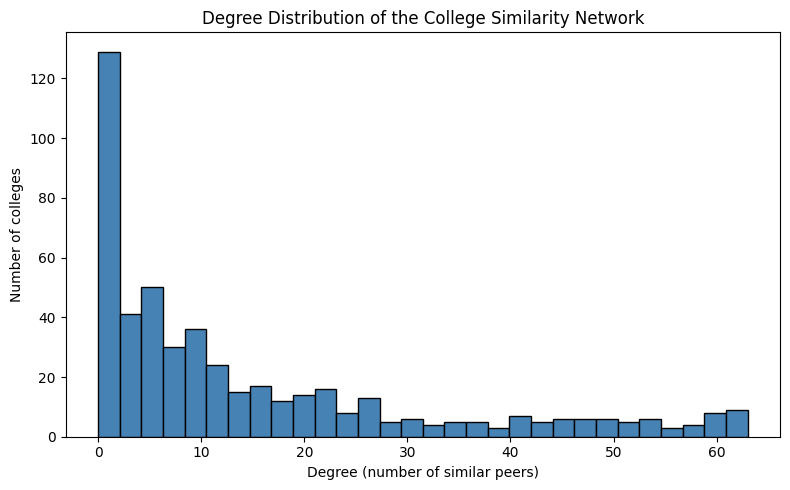

In [9]:
# Degree distribution: most colleges have a small handful of similar peers, while
# a few "hub" colleges sit in dense neighborhoods of look-alike institutions.
degrees = [d for _, d in G.degree()]

plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=30, color="steelblue", edgecolor="black")
plt.xlabel("Degree (number of similar peers)")
plt.ylabel("Number of colleges")
plt.title("Degree Distribution of the College Similarity Network")
plt.tight_layout()
plt.savefig("degree_distribution.png", dpi=150)
plt.show()

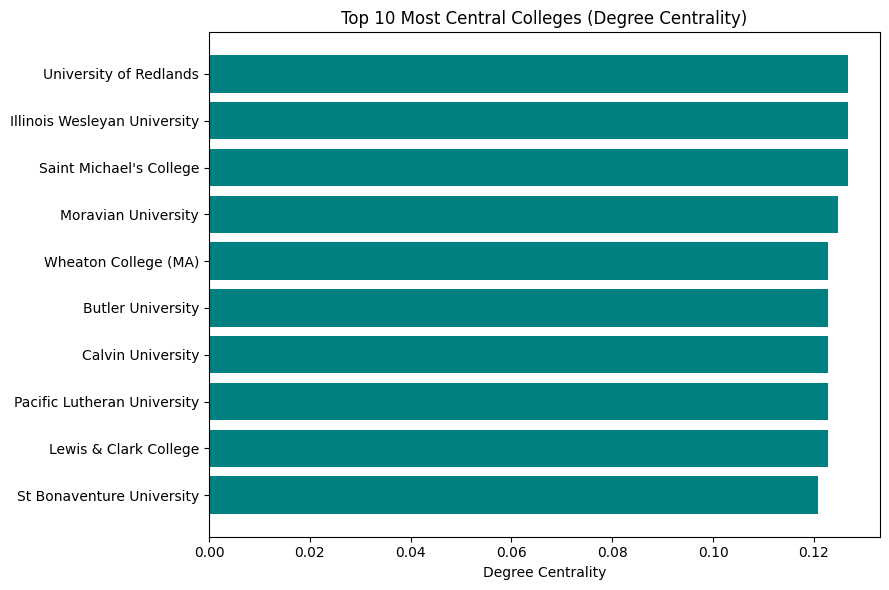

In [10]:
# Top 10 colleges by degree centrality - the most "representative" colleges,
# meaning they look like many other colleges in the dataset.
top_degree = centrality_df.sort_values("degree_centrality", ascending=False).head(10)

plt.figure(figsize=(9, 6))
plt.barh(top_degree["college"], top_degree["degree_centrality"], color="teal")
plt.gca().invert_yaxis()
plt.xlabel("Degree Centrality")
plt.title("Top 10 Most Central Colleges (Degree Centrality)")
plt.tight_layout()
plt.savefig("top_degree_centrality.png", dpi=150)
plt.show()

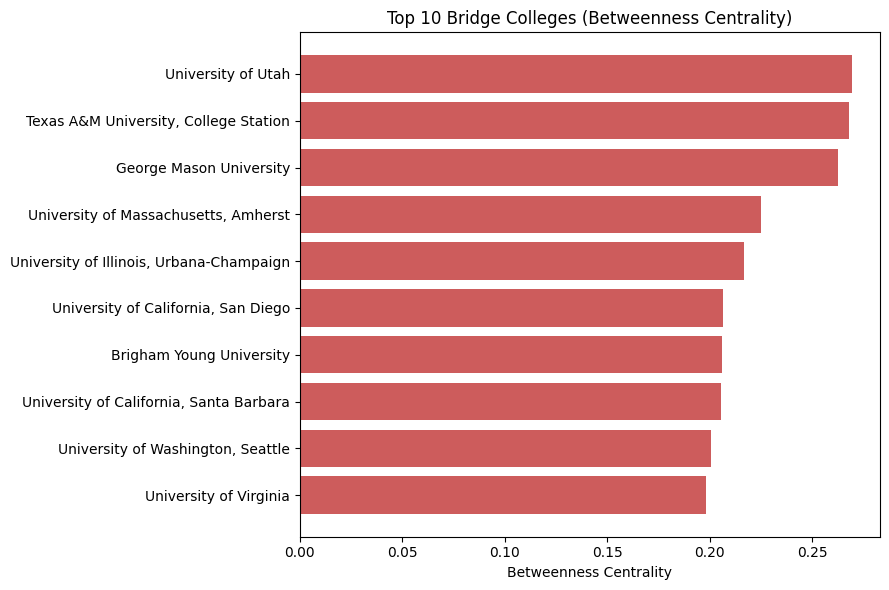

In [11]:
# Top 10 colleges by betweenness centrality - "bridge" colleges that connect
# otherwise-separate parts of the network (e.g. linking elite privates to large publics).
top_btw = centrality_df.sort_values("betweenness_centrality", ascending=False).head(10)

plt.figure(figsize=(9, 6))
plt.barh(top_btw["college"], top_btw["betweenness_centrality"], color="indianred")
plt.gca().invert_yaxis()
plt.xlabel("Betweenness Centrality")
plt.title("Top 10 Bridge Colleges (Betweenness Centrality)")
plt.tight_layout()
plt.savefig("top_betweenness_centrality.png", dpi=150)
plt.show()

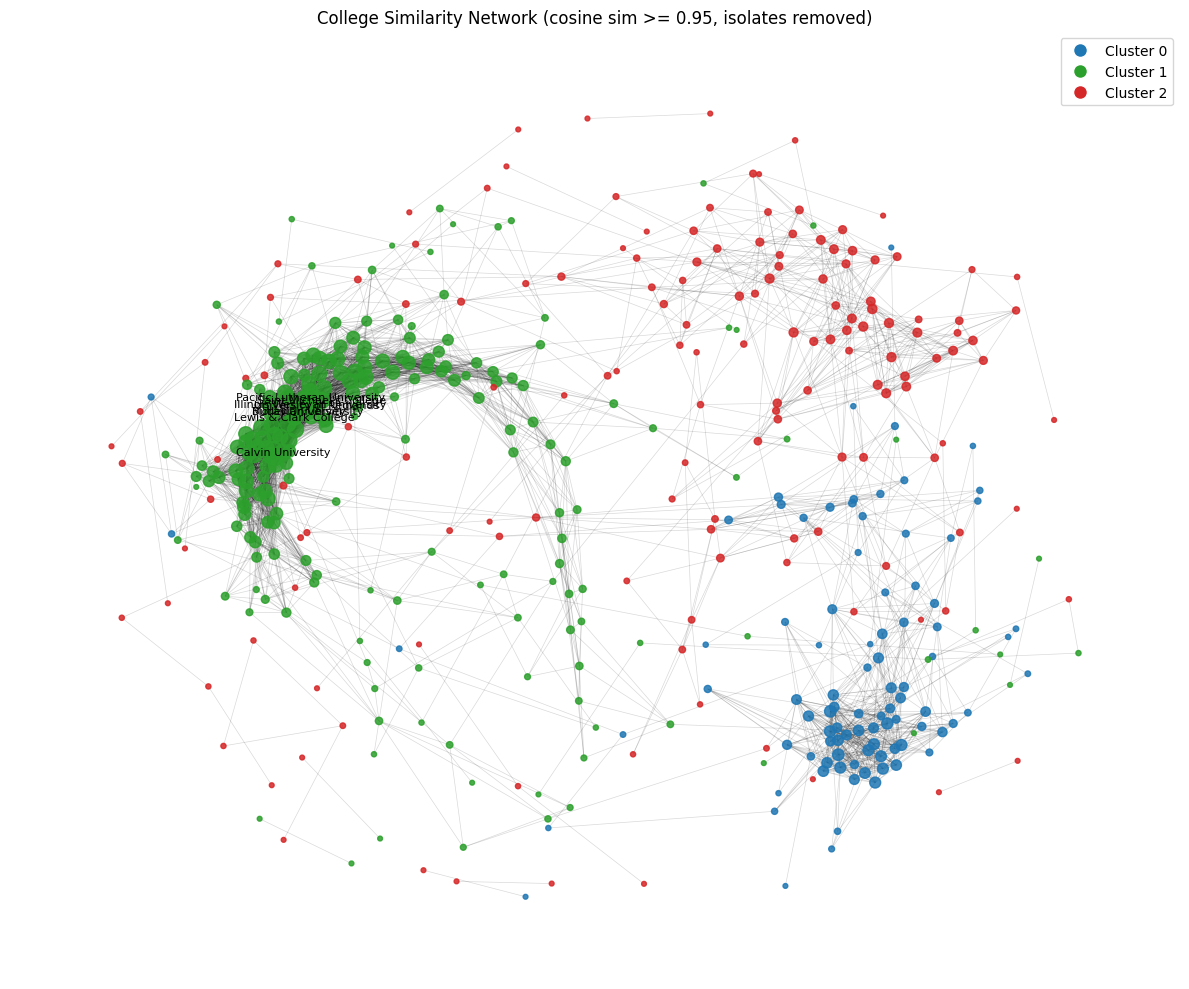

In [12]:
# Network visualization colored by KMeans cluster. We drop isolated nodes (no edges)
# so the layout is easier to read, and use a spring layout so similar colleges sit
# near each other. Node size scales with degree to highlight hubs.
G_vis = G.copy()
G_vis.remove_nodes_from([n for n, d in G_vis.degree() if d == 0])

pos = nx.spring_layout(G_vis, seed=42, k=0.25, iterations=50)

cluster_colors = {0: "#1f77b4", 1: "#2ca02c", 2: "#d62728"}
node_colors = [cluster_colors.get(G_vis.nodes[n]["cluster"], "gray") for n in G_vis.nodes()]
node_sizes = [10 + G_vis.degree(n) * 2 for n in G_vis.nodes()]

plt.figure(figsize=(12, 10))
nx.draw_networkx_edges(G_vis, pos, alpha=0.15, width=0.5)
nx.draw_networkx_nodes(G_vis, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85)

# label only the top 8 hubs to avoid clutter
top_hubs = sorted(G_vis.degree(), key=lambda x: x[1], reverse=True)[:8]
hub_labels = {n: n for n, _ in top_hubs}
nx.draw_networkx_labels(G_vis, pos, labels=hub_labels, font_size=8)

# manual legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
                           markersize=10, label=f"Cluster {k}") for k, c in cluster_colors.items()]
plt.legend(handles=legend_elements, loc="upper right")

plt.title(f"College Similarity Network (cosine sim >= {threshold}, isolates removed)")
plt.axis("off")
plt.tight_layout()
plt.savefig("network_graph.png", dpi=150)
plt.show()

In [13]:
# Export the graph to GEXF for Gephi. Node attributes (cluster, region, college type,
# salary, student pop) and edge weights are preserved so you can color/size/filter
# inside Gephi without rebuilding the graph.
nx.write_gexf(G, "college_network.gexf")

# Also export plain CSVs for nodes and edges - useful as a backup import path
# in Gephi (Data Laboratory > Import Spreadsheet).
nodes_export = pd.DataFrame([
    {
        "Id": n,
        "Label": n,
        "cluster": G.nodes[n]["cluster"],
        "state": G.nodes[n]["state"],
        "region": G.nodes[n]["region"],
        "collegeType": G.nodes[n]["collegeType"],
        "medianBaseSalary": G.nodes[n]["medianBaseSalary"],
        "totalStudentPop": G.nodes[n]["totalStudentPop"]
    }
    for n in G.nodes()
])
nodes_export.to_csv("gephi_nodes.csv", index=False)

edges_export = pd.DataFrame([
    {"Source": u, "Target": v, "Type": "Undirected", "Weight": d["weight"]}
    for u, v, d in G.edges(data=True)
])
edges_export.to_csv("gephi_edges.csv", index=False)

print("Exported:")
print("  college_network.gexf  (drag this into Gephi)")
print("  gephi_nodes.csv       (backup, import via Data Laboratory)")
print("  gephi_edges.csv       (backup, import via Data Laboratory)")

Exported:
  college_network.gexf  (drag this into Gephi)
  gephi_nodes.csv       (backup, import via Data Laboratory)
  gephi_edges.csv       (backup, import via Data Laboratory)
